# Comparaison Baseline vs Finetune — Prompt 2

Compare les scores (**macro F1**) et les erreurs entre le modèle baseline et le modèle finetuné, **globalement** et par type d'énoncé (**POL** vs **MEDICAL**).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import f1_score

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=["Contradiction", "Entailment"], average="macro")

# Dossier de sortie des graphiques (même convention que les autres notebooks du dossier)
GRAPHS_DIR = "graphes"
os.makedirs(GRAPHS_DIR, exist_ok=True)

# Chargement des CSV combined (baseline et finetune)
df_base = pd.read_csv("eval_clinical_matching_combined_baseline.csv")
df_fine = pd.read_csv("eval_clinical_matching_combined_finetune.csv")

# Fusion sur index pour comparer exemple par exemple
df = df_base[["index", "statement_type", "gold"]].copy()
df["pred_baseline"] = df_base["prediction"]
df["pred_finetune"] = df_fine["prediction"]
df["correct_baseline"] = df_base["is_correct"]
df["correct_finetune"] = df_fine["is_correct"]

print("Lignes chargées:", len(df))
df.head()

Lignes chargées: 3156


,index,statement_type,gold,pred_baseline,pred_finetune,correct_baseline,correct_finetune
0,0,pol,Entailment,Contradiction,Contradiction,False,False
1,1,pol,Contradiction,Entailment,Entailment,False,False
2,2,pol,Entailment,Entailment,Entailment,True,True
3,3,pol,Contradiction,Contradiction,Contradiction,True,True
4,4,pol,Contradiction,Contradiction,Entailment,True,False


Macro F1 (0–1) :


,Baseline,Finetune,Δ
statement_type,,,
pol,0.647272,0.722265,0.0750
medical,0.673395,0.713196,0.0398
Global,0.660612,0.717730,0.0571


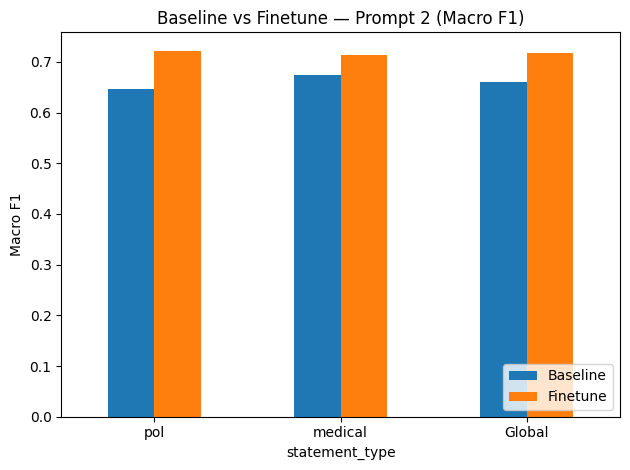

In [2]:
# Scores : macro F1 globale et par statement_type
rows = []
for stype in ["pol", "medical"]:
    sub = df[df["statement_type"] == stype]
    b, f = macro_f1(sub["gold"], sub["pred_baseline"]), macro_f1(sub["gold"], sub["pred_finetune"])
    rows.append((stype, b, f))
rows.append(("Global", macro_f1(df["gold"], df["pred_baseline"]), macro_f1(df["gold"], df["pred_finetune"])))
scores = pd.DataFrame(rows, columns=["statement_type", "Baseline", "Finetune"]).set_index("statement_type")
scores["Δ"] = (scores["Finetune"] - scores["Baseline"]).round(4)
print("Macro F1 (0–1) :")
display(scores)
scores[["Baseline", "Finetune"]].plot(kind="bar", ylabel="Macro F1", title="Baseline vs Finetune — Prompt 2 (Macro F1)", rot=0);
plt.legend(loc="lower right");
plt.tight_layout();
plt.savefig(os.path.join(GRAPHS_DIR, "prompt2_compare_baseline_finetune_macro_f1.png"), dpi=150, bbox_inches="tight");
plt.show();

Répartition des accords / désaccords :


,Les deux corrects,"Baseline faux, Finetune OK","Baseline OK, Finetune faux",Les deux faux
Global,1656,642,432,426
POL,813,343,212,210
MEDICAL,843,299,220,216


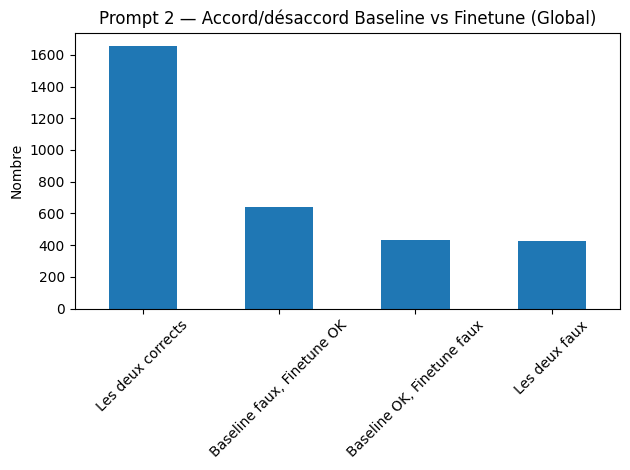

In [3]:
# Où se trompent-ils ? (mêmes endroits)
df["both_ok"]    = df["correct_baseline"] & df["correct_finetune"]
df["base_wrong"] = ~df["correct_baseline"] & df["correct_finetune"]   # finetune répare
df["fine_wrong"] = df["correct_baseline"] & ~df["correct_finetune"]   # régression
df["both_wrong"] = ~df["correct_baseline"] & ~df["correct_finetune"]  # même erreur

counts = pd.DataFrame({
    "Les deux corrects": [df["both_ok"].sum(), df[df["statement_type"]=="pol"]["both_ok"].sum(), df[df["statement_type"]=="medical"]["both_ok"].sum()],
    "Baseline faux, Finetune OK": [df["base_wrong"].sum(), df[df["statement_type"]=="pol"]["base_wrong"].sum(), df[df["statement_type"]=="medical"]["base_wrong"].sum()],
    "Baseline OK, Finetune faux": [df["fine_wrong"].sum(), df[df["statement_type"]=="pol"]["fine_wrong"].sum(), df[df["statement_type"]=="medical"]["fine_wrong"].sum()],
    "Les deux faux": [df["both_wrong"].sum(), df[df["statement_type"]=="pol"]["both_wrong"].sum(), df[df["statement_type"]=="medical"]["both_wrong"].sum()],
}, index=["Global", "POL", "MEDICAL"])
print("Répartition des accords / désaccords :")
display(counts)
# Graphique : répartition des 4 cas (global)
counts_global = counts.loc["Global"]
counts_global.plot(kind="bar", ylabel="Nombre", title="Prompt 2 — Accord/désaccord Baseline vs Finetune (Global)", rot=45);
plt.tight_layout();
plt.savefig(os.path.join(GRAPHS_DIR, "prompt2_compare_baseline_finetune_accord_desaccord.png"), dpi=150, bbox_inches="tight");
plt.show();

In [4]:
# Chevauchement des erreurs : % erreurs baseline corrigées, % régressions finetune
err_base = ~df["correct_baseline"]
err_fine = ~df["correct_finetune"]
fixed = err_base & df["correct_finetune"]
new_err = df["correct_baseline"] & err_fine

overlap = pd.DataFrame({
    "Erreurs baseline": [err_base.sum(), err_base[df["statement_type"]=="pol"].sum(), err_base[df["statement_type"]=="medical"].sum()],
    "% corrigées par finetune": [
        (fixed.sum() / err_base.sum() * 100) if err_base.sum() else 0,
        (fixed[df["statement_type"]=="pol"].sum() / err_base[df["statement_type"]=="pol"].sum() * 100) if err_base[df["statement_type"]=="pol"].sum() else 0,
        (fixed[df["statement_type"]=="medical"].sum() / err_base[df["statement_type"]=="medical"].sum() * 100) if err_base[df["statement_type"]=="medical"].sum() else 0,
    ],
    "Nouvelles erreurs finetune": [new_err.sum(), new_err[df["statement_type"]=="pol"].sum(), new_err[df["statement_type"]=="medical"].sum()],
}, index=["Global", "POL", "MEDICAL"])
print("Synthèse erreurs :")
display(overlap.round(2))

Synthèse erreurs :


,Erreurs baseline,% corrigées par finetune,Nouvelles erreurs finetune
Global,1068,60.11,432
POL,553,62.03,212
MEDICAL,515,58.06,220


In [5]:
# Rappel : le tableau et le graphique Macro F1 sont déjà affichés dans la cellule des scores ci-dessus.
# Synthèse Macro F1 (même calcul que ci-dessus, en % pour lecture)
print("=== Macro F1 Prompt 2 — Baseline vs Finetune (référence) ===")
rows = []
for stype in ["pol", "medical"]:
    sub = df[df["statement_type"] == stype]
    rows.append(
        (stype.upper(),
         100 * macro_f1(sub["gold"], sub["pred_baseline"]),
         100 * macro_f1(sub["gold"], sub["pred_finetune"]))
    )
rows.append(
    ("Global",
     100 * macro_f1(df["gold"], df["pred_baseline"]),
     100 * macro_f1(df["gold"], df["pred_finetune"]))
)
macro_scores = pd.DataFrame(rows, columns=["Set", "Baseline", "Finetune"]).set_index("Set")
macro_scores["Δ"] = (macro_scores["Finetune"] - macro_scores["Baseline"]).round(1)
display(macro_scores)

=== Macro F1 Prompt 2 — Baseline vs Finetune (référence) ===


,Baseline,Finetune,Δ
Set,,,
POL,64.727168,72.226513,7.5
MEDICAL,67.339500,71.319616,4.0
Global,66.061222,71.772962,5.7
